# Steps in ML projects

1. Look at the big picture.
2. Get the data.
3. Discover and visualize the data to gain insights.
4. Prepare the data for Machine Learning algorithms.
5. Select a model and train it.
6. Fine-tune your model.
7. Present your solution.
8. Launch, monitor and maintain your system.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crime-cast-forecasting-crime-categories/sample.csv
/kaggle/input/crime-cast-forecasting-crime-categories/train.csv
/kaggle/input/crime-cast-forecasting-crime-categories/test.csv


In [2]:
from sklearn.model_selection import train_test_split

# 2. Data Loading

In [3]:
train_df = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/train.csv")
X = train_df.drop('Crime_Category',axis='columns')
y = train_df['Crime_Category']

# 3. EDA

In [4]:
train_df.head()

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,N Hollywood,1563.0,...,75.0,M,W,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,Newton,1367.0,...,41.0,M,H,216.0,SWAP MEET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,Newton,1343.0,...,67.0,M,B,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Property Crimes
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,Mission,1924.0,...,61.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
4,7100 S VERMONT AV,NaN,33.9787,-118.2918,02/25/2020 12:00:00 AM,02/25/2020 12:00:00 AM,1130.0,12.0,77th Street,1245.0,...,0.0,X,X,401.0,MINI-MART,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               20000 non-null  object 
 1   Cross_Street           3448 non-null   object 
 2   Latitude               20000 non-null  float64
 3   Longitude              20000 non-null  float64
 4   Date_Reported          20000 non-null  object 
 5   Date_Occurred          20000 non-null  object 
 6   Time_Occurred          20000 non-null  float64
 7   Area_ID                20000 non-null  float64
 8   Area_Name              20000 non-null  object 
 9   Reporting_District_no  20000 non-null  float64
 10  Part 1-2               20000 non-null  float64
 11  Modus_Operandi         17259 non-null  object 
 12  Victim_Age             20000 non-null  float64
 13  Victim_Sex             17376 non-null  object 
 14  Victim_Descent         17376 non-null  object 
 15  Pr

In [6]:
train_df.describe()

,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Victim_Age,Premise_Code,Weapon_Used_Code
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,7335.000000
mean,33.940704,-117.893072,1352.380350,10.834250,1129.599200,1.418150,30.135000,297.176950,366.405044
std,2.126810,7.377726,646.100291,6.033166,603.330519,0.493267,21.863645,212.007298,120.485687
min,0.000000,-118.663400,1.000000,1.000000,101.000000,1.000000,-2.000000,101.000000,101.000000
25%,34.009200,-118.429700,930.000000,6.000000,632.000000,1.000000,12.000000,101.000000,312.000000
50%,34.058700,-118.323000,1430.000000,11.000000,1162.000000,1.000000,31.000000,203.000000,400.000000
75%,34.165025,-118.274400,1900.000000,16.000000,1622.000000,2.000000,46.000000,501.000000,400.000000
max,34.328100,0.000000,2359.000000,21.000000,2197.000000,2.000000,99.000000,969.000000,515.000000


In [7]:
# Descriptive statistics for numeric columns
print(train_df.describe())

# Value counts for categorical columns
print(train_df['Crime_Category'].value_counts())
print(train_df['Victim_Sex'].value_counts())

           Latitude     Longitude  Time_Occurred       Area_ID  \
count  20000.000000  20000.000000   20000.000000  20000.000000   
mean      33.940704   -117.893072    1352.380350     10.834250   
std        2.126810      7.377726     646.100291      6.033166   
min        0.000000   -118.663400       1.000000      1.000000   
25%       34.009200   -118.429700     930.000000      6.000000   
50%       34.058700   -118.323000    1430.000000     11.000000   
75%       34.165025   -118.274400    1900.000000     16.000000   
max       34.328100      0.000000    2359.000000     21.000000   

       Reporting_District_no      Part 1-2    Victim_Age  Premise_Code  \
count           20000.000000  20000.000000  20000.000000  20000.000000   
mean             1129.599200      1.418150     30.135000    297.176950   
std               603.330519      0.493267     21.863645    212.007298   
min               101.000000      1.000000     -2.000000    101.000000   
25%               632.000000      1

Location                     0
Cross_Street             16552
Latitude                     0
Longitude                    0
Date_Reported                0
Date_Occurred                0
Time_Occurred                0
Area_ID                      0
Area_Name                    0
Reporting_District_no        0
Part 1-2                     0
Modus_Operandi            2741
Victim_Age                   0
Victim_Sex                2624
Victim_Descent            2624
Premise_Code                 0
Premise_Description          5
Weapon_Used_Code         12665
Weapon_Description       12665
Status                       0
Status_Description           0
Crime_Category               0
dtype: int64
13


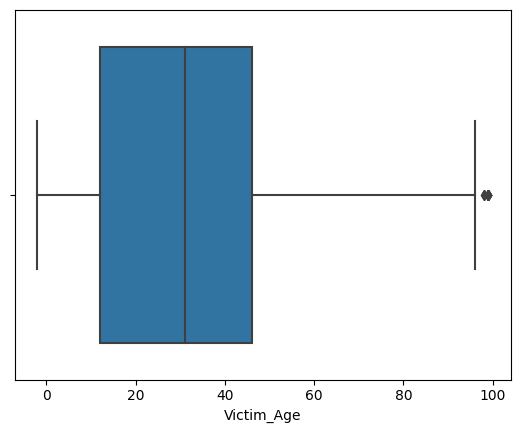

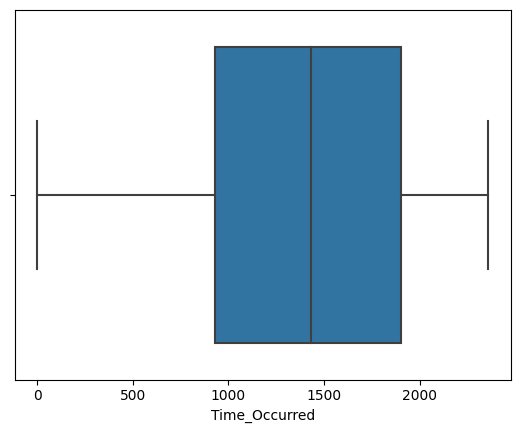

In [8]:
# Missing values
print(train_df.isnull().sum())

# Duplicate entries
print(train_df.duplicated().sum())

# Outliers detection
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for Victim_Age
sns.boxplot(x=train_df['Victim_Age'])
plt.show()

# Boxplot for Time_Occurred
sns.boxplot(x=train_df['Time_Occurred'])
plt.show()


**Handling the negative and zero age values**

In [9]:
import numpy as np
from sklearn.impute import KNNImputer
import pandas as pd

# Assuming train_df is already loaded with the relevant data

# Replace non-positive values in 'Victim_Age' with NaN
train_df['Victim_Age'] = train_df['Victim_Age'].apply(lambda x: np.nan if x <= 0 else x)

# Initialize KNNImputer with a specified number of neighbors
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNN Imputer only to the 'Victim_Age' column
train_df[['Victim_Age']] = knn_imputer.fit_transform(train_df[['Victim_Age']])

# Verify the imputation
print(train_df['Victim_Age'].describe())

count    20000.000000
mean        39.740736
std         13.730228
min          2.000000
25%         30.000000
50%         39.740736
75%         46.000000
max         99.000000
Name: Victim_Age, dtype: float64


In [10]:
Q1 = train_df[['Victim_Age', 'Time_Occurred']].quantile(0.25)
Q3 = train_df[['Victim_Age', 'Time_Occurred']].quantile(0.75)
IQR = Q3 - Q1

outliers = (train_df[['Victim_Age', 'Time_Occurred']] < (Q1 - 1.5 * IQR)) | (train_df[['Victim_Age', 'Time_Occurred']] > (Q3 + 1.5 * IQR))
outliers = outliers.any(axis=1)
outliers_indices = train_df.index[outliers]
print(train_df.loc[outliers_indices])

                                       Location Cross_Street  Latitude  \
0       4500    CARPENTER                    AV          NaN   34.1522   
18      3200    GRAND VIEW                   BL          NaN   34.0150   
43     15700    WOODVALE                     RD          NaN   34.1529   
47              SHERMAN                      WY       KESTER   34.2013   
104     3700    LEE                          ST          NaN   34.0219   
...                                         ...          ...       ...   
19842   5500    FALLBROOK                    AV          NaN   34.1701   
19871                                   MERCURY     BOUNDARY   34.0859   
19892   1100 W  24TH                         ST          NaN   33.7225   
19965   5000    CALATRANA                    DR          NaN   34.1592   
19998    300 W  SEPULVEDA                    ST          NaN   33.7451   

       Longitude           Date_Reported           Date_Occurred  \
0      -118.3910  03/09/2020 12:00:00 AM  0

In [11]:
median_age = train_df['Victim_Age'].median()
median_time = train_df['Time_Occurred'].median()

train_df.loc[outliers, 'Victim_Age'] = median_age
train_df.loc[outliers, 'Time_Occurred'] = median_time

In [12]:
# Summary statistics after imputation
print(train_df['Victim_Age'].describe())

count    20000.000000
mean        38.685256
std         11.876252
min          6.000000
25%         31.000000
50%         39.740736
75%         43.000000
max         70.000000
Name: Victim_Age, dtype: float64


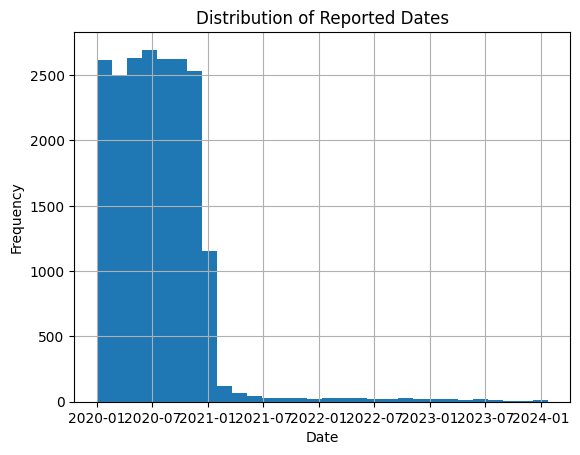

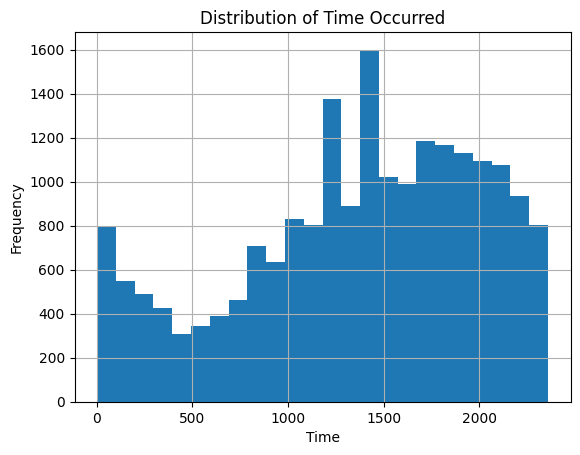

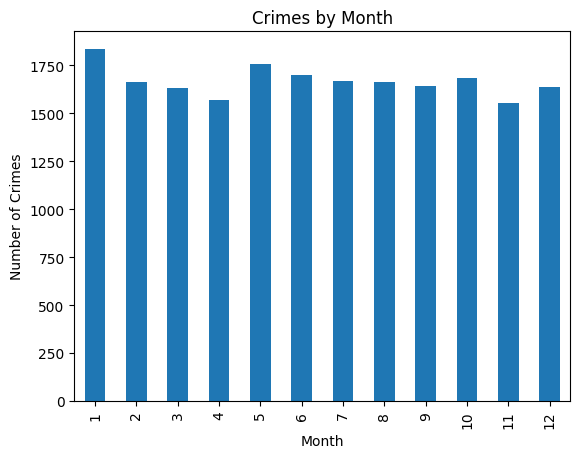

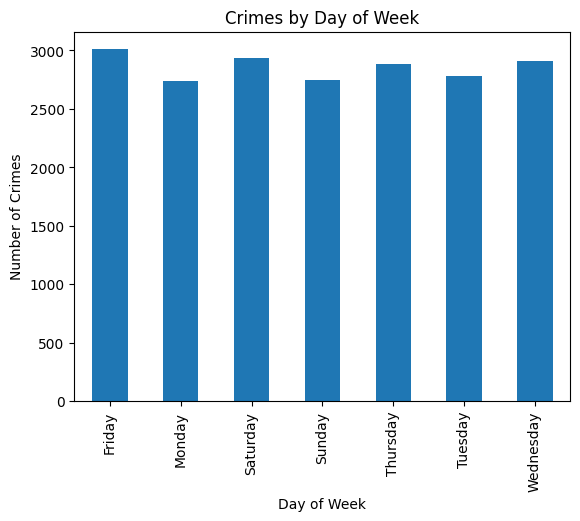

In [13]:
# Convert to datetime
train_df['Date_Reported'] = pd.to_datetime(train_df['Date_Reported'], format='%m/%d/%Y %I:%M:%S %p')
train_df['Date_Occurred'] = pd.to_datetime(train_df['Date_Occurred'], format='%m/%d/%Y %I:%M:%S %p')

# Date distribution
train_df['Date_Reported'].hist(bins=30)
plt.title('Distribution of Reported Dates')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.show()

# Time of crime distribution
train_df['Time_Occurred'].hist(bins=24)
plt.title('Distribution of Time Occurred')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

# Seasonal trends
train_df['Month'] = train_df['Date_Occurred'].dt.month
train_df['Day_of_Week'] = train_df['Date_Occurred'].dt.day_name()

train_df.groupby('Month').size().plot(kind='bar')
plt.title('Crimes by Month')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.show()

train_df.groupby('Day_of_Week').size().plot(kind='bar')
plt.title('Crimes by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Crimes')
plt.show()

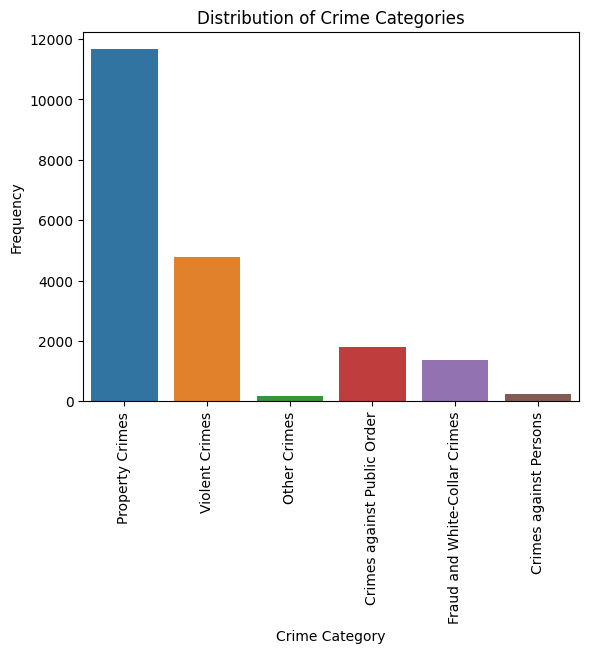

Victim_Sex                        F  H     M     X
Crime_Category                                    
Crimes against Persons          133  0    91     1
Crimes against Public Order     888  0   768   152
Fraud and White-Collar Crimes   623  1   628    69
Other Crimes                     49  0    84    46
Property Crimes                3016  1  4721  1339
Violent Crimes                 2467  0  2246    53


In [14]:
# Crime Category distribution
sns.countplot(x='Crime_Category', data=train_df)
plt.xticks(rotation=90)
plt.title('Distribution of Crime Categories')
plt.xlabel('Crime Category')
plt.ylabel('Frequency')
plt.show()

# Cross-tabulation
cross_tab = pd.crosstab(train_df['Crime_Category'], train_df['Victim_Sex'])
print(cross_tab)

In [15]:
# Common Modus Operandi
print(train_df['Modus_Operandi'].value_counts().head(10))

# Weapon Analysis
print(train_df['Weapon_Description'].value_counts().head(10))

Modus_Operandi
0344         826
0329         583
1501         187
0329 1300    135
0325         127
0344 1300    114
0344 1822    108
1822 0344    108
0329 1822    103
0344 0394     97
Name: count, dtype: int64
Weapon_Description
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    3990
UNKNOWN WEAPON/OTHER WEAPON                        789
VERBAL THREAT                                      546
HAND GUN                                           388
KNIFE WITH BLADE 6INCHES OR LESS                   160
SEMI-AUTOMATIC PISTOL                              154
UNKNOWN FIREARM                                    131
OTHER KNIFE                                        125
VEHICLE                                             84
MACE/PEPPER SPRAY                                   80
Name: count, dtype: int64


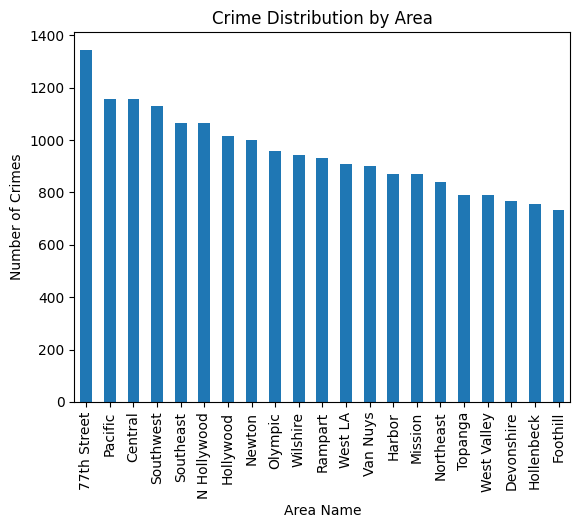

Cross_Street
BROADWAY                           56
FIGUEROA                           43
VERMONT                      AV    40
FIGUEROA                     ST    34
MAIN                               33
MAIN                         ST    30
SAN PEDRO                          28
SAN PEDRO                    ST    26
WESTERN                      AV    25
WILSHIRE                           23
Name: count, dtype: int64


In [16]:
# Area-wise Crime Distribution
area_distribution = train_df['Area_Name'].value_counts()
area_distribution.plot(kind='bar')
plt.title('Crime Distribution by Area')
plt.xlabel('Area Name')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=90)
plt.show()

# Cross Street Analysis
print(train_df['Cross_Street'].value_counts().head(10))

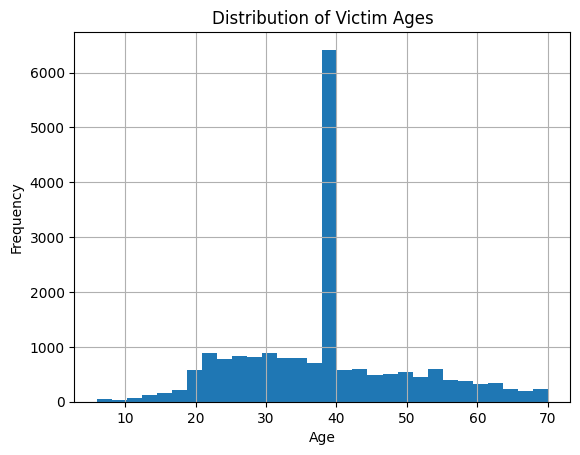

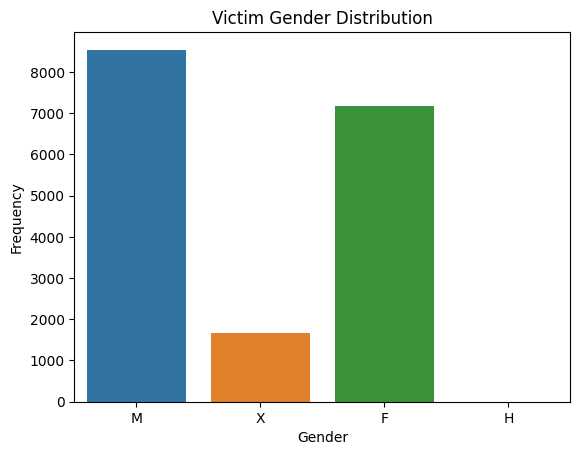

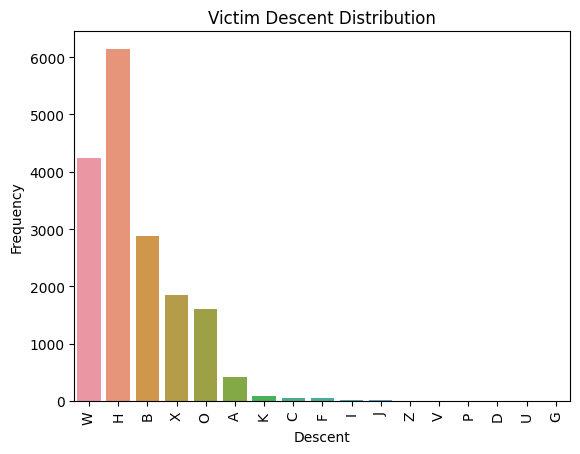

In [17]:
# Age Distribution
train_df['Victim_Age'].hist(bins=30)
plt.title('Distribution of Victim Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Gender Distribution
sns.countplot(x='Victim_Sex', data=train_df)
plt.title('Victim Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

# Descent Distribution
sns.countplot(x='Victim_Descent', data=train_df)
plt.title('Victim Descent Distribution')
plt.xlabel('Descent')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

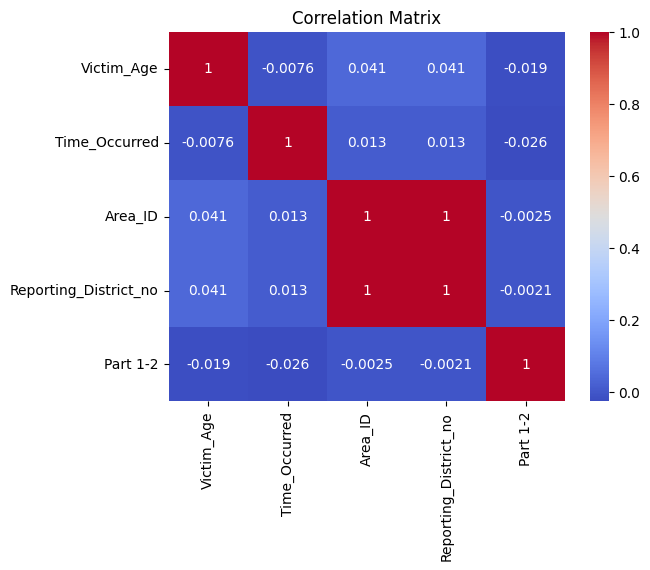

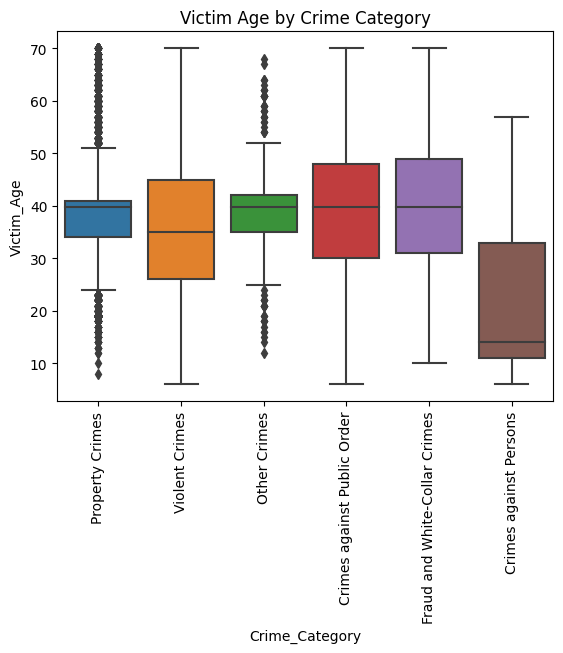

In [18]:
# Correlation Matrix
correlation_matrix = train_df[['Victim_Age', 'Time_Occurred', 'Area_ID', 'Reporting_District_no', 'Part 1-2']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Crime vs. Victim Attributes
sns.boxplot(x='Crime_Category', y='Victim_Age', data=train_df)
plt.title('Victim Age by Crime Category')
plt.xticks(rotation=90)
plt.show()

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

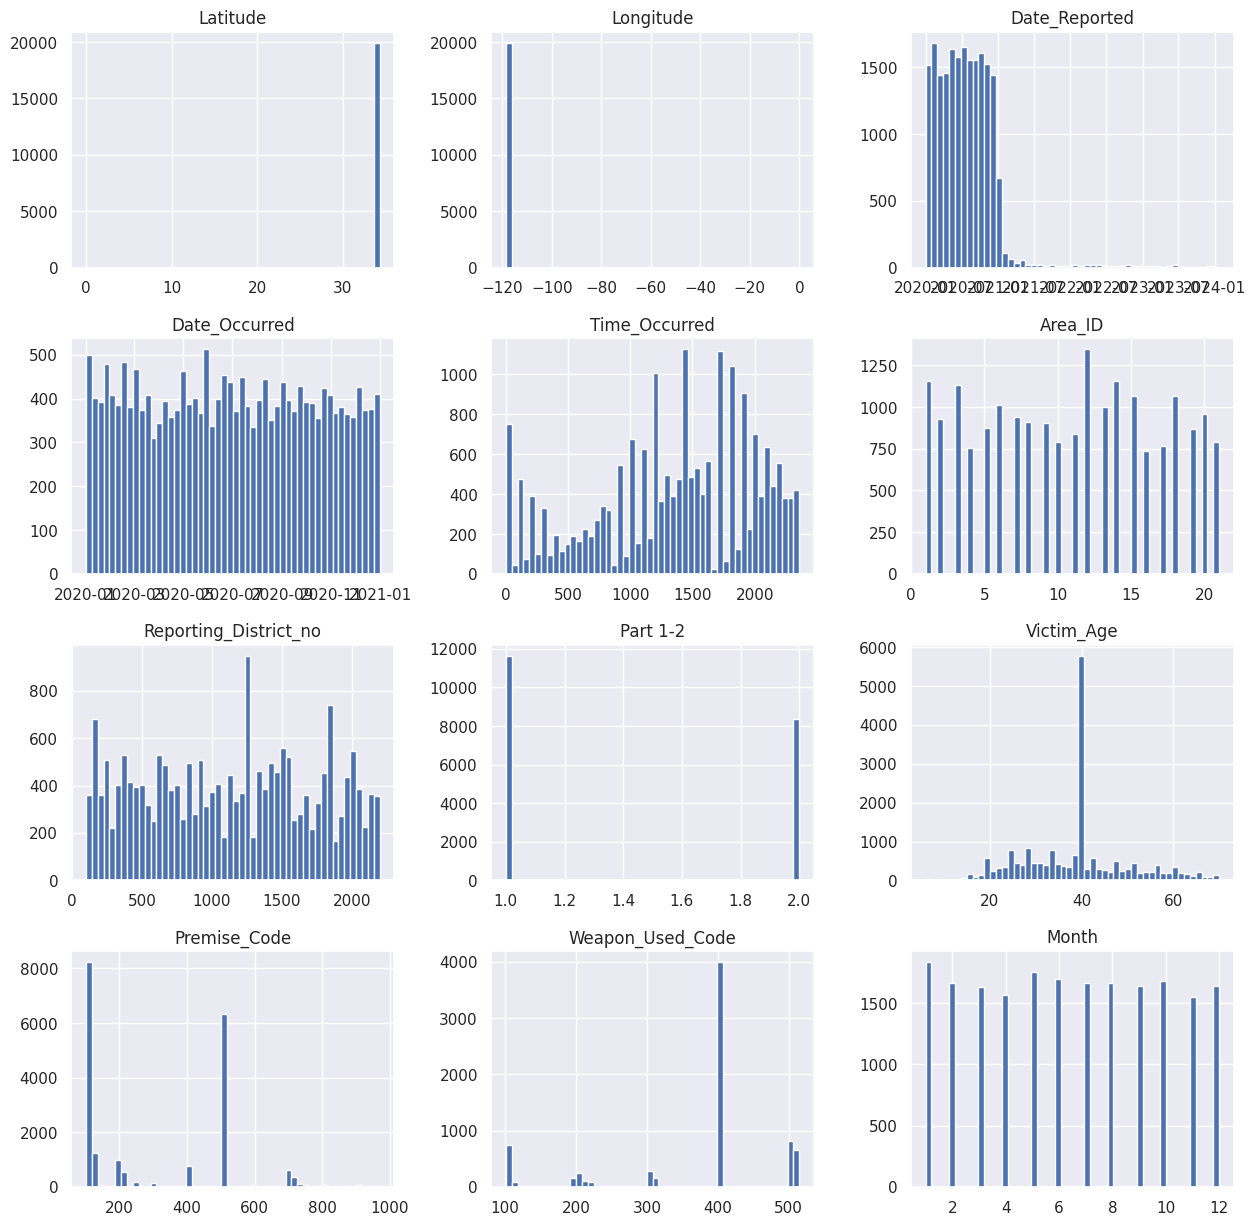

In [20]:
sns.set()
train_df.hist(bins=50,figsize=(15,15))
# display histogram
plt.show()

In [21]:
y.head()

0    Property Crimes
1    Property Crimes
2    Property Crimes
3    Property Crimes
4    Property Crimes
Name: Crime_Category, dtype: object

In [22]:
X.head()

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Modus_Operandi,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,N Hollywood,1563.0,...,0385,75.0,M,W,101.0,STREET,NaN,NaN,IC,Invest Cont
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,Newton,1367.0,...,0906 0352 0371 0446 1822 0344 0416 0417,41.0,M,H,216.0,SWAP MEET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,Newton,1343.0,...,0329 1202,67.0,M,B,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,Mission,1924.0,...,0329 1300,61.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont
4,7100 S VERMONT AV,NaN,33.9787,-118.2918,02/25/2020 12:00:00 AM,02/25/2020 12:00:00 AM,1130.0,12.0,77th Street,1245.0,...,0416 0945 1822 0400 0417 0344,0.0,X,X,401.0,MINI-MART,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont


In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               20000 non-null  object 
 1   Cross_Street           3448 non-null   object 
 2   Latitude               20000 non-null  float64
 3   Longitude              20000 non-null  float64
 4   Date_Reported          20000 non-null  object 
 5   Date_Occurred          20000 non-null  object 
 6   Time_Occurred          20000 non-null  float64
 7   Area_ID                20000 non-null  float64
 8   Area_Name              20000 non-null  object 
 9   Reporting_District_no  20000 non-null  float64
 10  Part 1-2               20000 non-null  float64
 11  Modus_Operandi         17259 non-null  object 
 12  Victim_Age             20000 non-null  float64
 13  Victim_Sex             17376 non-null  object 
 14  Victim_Descent         17376 non-null  object 
 15  Pr

In [24]:
X.columns

Index(['Location', 'Cross_Street', 'Latitude', 'Longitude', 'Date_Reported',
       'Date_Occurred', 'Time_Occurred', 'Area_ID', 'Area_Name',
       'Reporting_District_no', 'Part 1-2', 'Modus_Operandi', 'Victim_Age',
       'Victim_Sex', 'Victim_Descent', 'Premise_Code', 'Premise_Description',
       'Weapon_Used_Code', 'Weapon_Description', 'Status',
       'Status_Description'],
      dtype='object')

In [25]:
X.nunique()

Location                 12399
Cross_Street              1495
Latitude                  3622
Longitude                 3578
Date_Reported              811
Date_Occurred              366
Time_Occurred              996
Area_ID                     21
Area_Name                   21
Reporting_District_no     1120
Part 1-2                     2
Modus_Operandi           10489
Victim_Age                 100
Victim_Sex                   4
Victim_Descent              17
Premise_Code               217
Premise_Description        216
Weapon_Used_Code            57
Weapon_Description          57
Status                       5
Status_Description           5
dtype: int64

In [26]:
X['Victim_Sex'].unique()

array(['M', 'X', 'F', nan, 'H'], dtype=object)

In [27]:
X['Status'].unique()

array(['IC', 'AO', 'AA', 'JA', 'JO'], dtype=object)

In [28]:
y.unique()

array(['Property Crimes', 'Violent Crimes', 'Other Crimes',
       'Crimes against Public Order', 'Fraud and White-Collar Crimes',
       'Crimes against Persons'], dtype=object)

In [29]:
X.isna().sum()

#To find out the missing values in X

Location                     0
Cross_Street             16552
Latitude                     0
Longitude                    0
Date_Reported                0
Date_Occurred                0
Time_Occurred                0
Area_ID                      0
Area_Name                    0
Reporting_District_no        0
Part 1-2                     0
Modus_Operandi            2741
Victim_Age                   0
Victim_Sex                2624
Victim_Descent            2624
Premise_Code                 0
Premise_Description          5
Weapon_Used_Code         12665
Weapon_Description       12665
Status                       0
Status_Description           0
dtype: int64

In [30]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               20000 non-null  object 
 1   Cross_Street           3448 non-null   object 
 2   Latitude               20000 non-null  float64
 3   Longitude              20000 non-null  float64
 4   Date_Reported          20000 non-null  object 
 5   Date_Occurred          20000 non-null  object 
 6   Time_Occurred          20000 non-null  float64
 7   Area_ID                20000 non-null  float64
 8   Area_Name              20000 non-null  object 
 9   Reporting_District_no  20000 non-null  float64
 10  Part 1-2               20000 non-null  float64
 11  Modus_Operandi         17259 non-null  object 
 12  Victim_Age             20000 non-null  float64
 13  Victim_Sex             17376 non-null  object 
 14  Victim_Descent         17376 non-null  object 
 15  Pr

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=42)

In [32]:
#X_train=X_train.drop(['Area_Name','Part 1-2', 'Premise_Description', 'Weapon_Description', 'Status_Description'], axis=1)

In [33]:
#X_val=X_val.drop(['Area_Name','Part 1-2', 'Premise_Description', 'Weapon_Description', 'Status_Description'], axis=1)

# 4. Preparing the Data for ML Algorithm

In [34]:
#Approach 1: Encode dataframe- Impute numbers - Scale the dataframe
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

transform_pipeline = Pipeline([
    ('encoder', OrdinalEncoder()),  # Encode other categorical columns
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])

# Transform the numerical and other categorical columns
transformed_df = transform_pipeline.fit_transform(X_train)
transformed_df = pd.DataFrame(transformed_df, columns=X_train.columns)

In [35]:
transformed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13400 entries, 0 to 13399
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               13400 non-null  float64
 1   Cross_Street           13400 non-null  float64
 2   Latitude               13400 non-null  float64
 3   Longitude              13400 non-null  float64
 4   Date_Reported          13400 non-null  float64
 5   Date_Occurred          13400 non-null  float64
 6   Time_Occurred          13400 non-null  float64
 7   Area_ID                13400 non-null  float64
 8   Area_Name              13400 non-null  float64
 9   Reporting_District_no  13400 non-null  float64
 10  Part 1-2               13400 non-null  float64
 11  Modus_Operandi         13400 non-null  float64
 12  Victim_Age             13400 non-null  float64
 13  Victim_Sex             13400 non-null  float64
 14  Victim_Descent         13400 non-null  float64
 15  Pr

In [36]:
transformed_df.head()

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Modus_Operandi,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description
0,0.104467,0.017856,-0.736198,0.041837,-1.300137,-1.238997,-1.160595,-1.305933,0.844861,-1.236367,...,-1.526883,1.982317,-1.289361,-1.471493,0.990897,-0.339745,0.243873,0.172214,0.486204,0.486204
1,0.819626,0.017856,1.161482,-2.012493,-0.639317,-0.701003,-1.000994,1.685548,1.008551,1.720671,...,-1.124878,0.729864,-1.289361,1.260580,1.801976,0.245757,0.243873,0.172214,0.486204,0.486204
2,-0.155591,0.017856,-0.211822,0.509063,-1.531917,1.432096,1.664764,1.519355,0.190100,1.569834,...,-1.531300,-1.357558,1.549677,1.470740,0.969553,0.526798,0.243873,0.172214,0.486204,0.486204
3,-0.335659,0.017856,-1.982227,1.752152,-0.003155,-0.125255,-0.724929,-1.139739,-0.792041,-1.094957,...,1.865857,0.358767,0.603331,-0.420695,0.990897,-0.339745,0.243873,0.172214,0.486204,0.486204
4,0.620930,0.017856,1.044389,-1.727033,-1.300137,-1.248435,0.698534,-0.142579,1.499622,-0.177364,...,-0.588382,-0.893687,0.603331,-1.471493,0.990897,-0.339745,0.355657,1.133284,-2.541977,-2.541977


In [37]:
#Approach 2: Impute constants - Encode numbers - Scale the dataframe
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer # Not used in this version
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
import numpy as np

transformer_list = [
    ('cat_const1', SimpleImputer(missing_values=np.nan,strategy= 'constant',fill_value="Unknown"), ['Cross_Street']),
    ('cat_const3', SimpleImputer(missing_values=np.nan,strategy= 'constant',fill_value="Unknown"), ['Victim_Sex']),
    ('cat_const4', SimpleImputer(missing_values=np.nan,strategy= 'constant',fill_value="Unknown"), ['Victim_Descent']),
    
    ('cat_mode4', SimpleImputer(missing_values=np.nan,strategy= 'most_frequent'), ['Weapon_Used_Code']),
    
]

# Handle Modus Operandi using the same pipeline
# Join tokens in 'Modus_Operandi' into strings if they are lists

transform_pipeline2 = Pipeline([('ct', ColumnTransformer(transformers = transformer_list, remainder='passthrough',verbose_feature_names_out=False).set_output(transform="pandas")),
                               ('encoder2', OrdinalEncoder()),
                               ('std_scaler2', StandardScaler()),])

# Transform all columns (including 'Modus_Operandi')
transformed_df2 = transform_pipeline2.fit_transform(X_train) 
transformed_df2 = pd.DataFrame(transformed_df2, columns=X_train.columns) 

# Now X_train_final contains all your features and should have the same number of columns as X_train
transformed_df2.head()

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Modus_Operandi,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description
0,0.338554,-1.201132,-1.555035,0.243873,0.104467,-0.736198,0.041837,-1.300137,-1.238997,-1.160595,...,0.844861,-1.236367,1.175679,-1.431937,1.982317,0.990897,-0.339557,NaN,0.486204,0.486204
1,0.338554,-1.201132,1.089194,0.243873,0.819626,1.161482,-2.012493,-0.639317,-0.701003,-1.000994,...,1.008551,1.720671,-0.850572,-1.058598,0.729864,1.801976,0.245880,NaN,0.486204,0.486204
2,0.338554,1.844023,1.278067,0.243873,-0.155591,-0.211822,0.509063,-1.531917,1.432096,1.664764,...,0.190100,1.569834,1.175679,-1.436039,-1.357558,0.969553,0.526890,NaN,0.486204,0.486204
3,0.338554,0.321446,-0.610667,0.243873,-0.335659,-1.982227,1.752152,-0.003155,-0.125255,-0.724929,...,-0.792041,-1.094957,1.175679,1.718881,0.358767,0.990897,-0.339557,NaN,0.486204,0.486204
4,0.338554,0.321446,-1.555035,0.355657,0.620930,1.044389,-1.727033,-1.300137,-1.248435,0.698534,...,1.499622,-0.177364,1.175679,-0.560356,-0.893687,0.990897,-0.339557,0.888432,-2.541977,-2.541977


In [38]:
transformed_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13400 entries, 0 to 13399
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               13400 non-null  float64
 1   Cross_Street           13400 non-null  float64
 2   Latitude               13400 non-null  float64
 3   Longitude              13400 non-null  float64
 4   Date_Reported          13400 non-null  float64
 5   Date_Occurred          13400 non-null  float64
 6   Time_Occurred          13400 non-null  float64
 7   Area_ID                13400 non-null  float64
 8   Area_Name              13400 non-null  float64
 9   Reporting_District_no  13400 non-null  float64
 10  Part 1-2               13400 non-null  float64
 11  Modus_Operandi         13400 non-null  float64
 12  Victim_Age             13400 non-null  float64
 13  Victim_Sex             13400 non-null  float64
 14  Victim_Descent         11541 non-null  float64
 15  Pr

Handled all the features till here. Next, labels. 

In [39]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 20000 entries, 0 to 19999
Series name: Crime_Category
Non-Null Count  Dtype 
--------------  ----- 
20000 non-null  object
dtypes: object(1)
memory usage: 156.4+ KB


In [40]:
#Not required
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded=label_encoder.fit_transform(y_train)
print(type(y_train_encoded))

<class 'numpy.ndarray'>


In [41]:
#print(type(y_tr))

In [42]:
#print(y_tr.shape)

In [43]:
#y_tr = pd.DataFrame(y_tr, columns=['Label'])
#print(type(y_tr))

In [44]:
#y_tr.info()

# 5. Selecting and Training a ML Model

## 1.2 Selection of performance measure

* Regression
  *  Mean Squared Error (MSE) or
  *  Mean Absolute Error (MAE)
* Classification
  *  Precision
  *  Recall
  *  F1-score
  *  Accuracy

In [45]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

In [46]:
model = DummyClassifier(strategy = "most_frequent")
model.fit(transformed_df,y_train)

DummyClassifier(strategy='most_frequent')

In [47]:
model2 = DecisionTreeClassifier()
model2.fit(transformed_df,y_train)

DecisionTreeClassifier()

In [48]:
model3 = BaggingClassifier()
model3.fit(transformed_df, y_train) #0.83

BaggingClassifier()

In [49]:
model4 = AdaBoostClassifier()
model4.fit(transformed_df, y_train)

AdaBoostClassifier()

In [50]:
model5 = GradientBoostingClassifier()
model5.fit(transformed_df, y_train) #0.85

GradientBoostingClassifier()

In [51]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors = 3) 
clf.fit(transformed_df, y_train) 

KNeighborsClassifier(n_neighbors=3)

In [52]:
from sklearn.svm import SVC 

svm = SVC(kernel="rbf", gamma=0.5, C=1.0) 
svm.fit(transformed_df, y_train)

SVC(gamma=0.5)

In [53]:
#model6 = MLPClassifier()
#model6.fit(transformed_df, y_train) Not converging

In [54]:
# model.predict(X_val.iloc[0:1])

In [55]:
#X_val.iloc[0:1]

In [56]:
from sklearn.metrics import precision_score,recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_val_score


X_val_transformed = transform_pipeline.fit_transform(X_val) #Transforming the validation set
X_val_transformed = pd.DataFrame(X_val_transformed, columns=X_train.columns) #Converting array into dataframe
y_pred_val = model5.predict(X_val_transformed) #Predicting the validation set
print("Accuracy score:", accuracy_score(y_val, y_pred_val)) 
print("Precision Score:",precision_score(y_val, y_pred_val, average="weighted"))
print("Recall Score:",recall_score(y_val, y_pred_val, average="weighted"))
print('F1 Score:', f1_score(y_val, y_pred_val, average="weighted"))
print()
def display_scores(scores):
    print("CV Scores:", scores)
    print("Mean CV Score:", scores.mean())
    print("CV Scores Standard deviation:", scores.std())


score = cross_val_score (model5, X_val_transformed, y_pred_val, cv=5)
display_scores(score)

Accuracy score: 0.8504545454545455
Precision Score: 0.8535853991827617
Recall Score: 0.8504545454545455
F1 Score: 0.847399073787366

CV Scores: [0.94242424 0.94242424 0.95378788 0.94772727 0.93484848]
Mean CV Score: 0.9442424242424241
CV Scores Standard deviation: 0.006294720629648786


In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred_val))

                               precision    recall  f1-score   support

       Crimes against Persons       0.61      0.62      0.62        66
  Crimes against Public Order       0.75      0.55      0.63       598
Fraud and White-Collar Crimes       0.85      0.67      0.75       461
                 Other Crimes       0.35      0.11      0.16        65
              Property Crimes       0.95      0.93      0.94      3808
               Violent Crimes       0.70      0.86      0.77      1602

                     accuracy                           0.85      6600
                    macro avg       0.70      0.62      0.65      6600
                 weighted avg       0.85      0.85      0.85      6600



# 6. Finetuning the ML Model

# of SVM

In [58]:
'''from sklearn.model_selection import GridSearchCV 
from sklearn.svm import SVC
#0.1, 1, 10, 100, 1000
# defining parameter range 
param_grid = {'C': [0.1, 1, 10, 100], 
            'gamma': [0.1, 0.01, 0.001, 0.0001], 
            'kernel': ['rbf']} 

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 

# fitting the model for grid search 
grid.fit(transformed_df, y_train)'''

'''Best combination: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=100, gamma=0.01) 

Accuracy score: 0.703030303030303
Precision Score: 0.6877296651877802
Recall Score: 0.703030303030303
F1 Score: 0.6676796862625628

Mean CV Score: 0.9318181818181817
CV Scores Standard deviation: 0.005525631069336515
'''

"Best combination: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}\nSVC(C=100, gamma=0.01) \n\nAccuracy score: 0.703030303030303\nPrecision Score: 0.6877296651877802\nRecall Score: 0.703030303030303\nF1 Score: 0.6676796862625628\n\nMean CV Score: 0.9318181818181817\nCV Scores Standard deviation: 0.005525631069336515\n"

In [59]:
'''# print best parameter after tuning 
print(grid.best_params_) 

# print how our model looks after hyper-parameter tuning 
print(grid.best_estimator_)'''

'# print best parameter after tuning \nprint(grid.best_params_) \n\n# print how our model looks after hyper-parameter tuning \nprint(grid.best_estimator_)'

In [60]:
#print(grid.cv_results_)

In [61]:
'''y_pred_val = grid.best_estimator_.predict(X_val_transformed) #Predicting the validation set
print("Accuracy score:", accuracy_score(y_val, y_pred_val)) 
print("Precision Score:",precision_score(y_val, y_pred_val, average="weighted"))
print("Recall Score:",recall_score(y_val, y_pred_val, average="weighted"))
print('F1 Score:', f1_score(y_val, y_pred_val, average="weighted"))
print()

from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("CV Scores:", scores)
    print("Mean CV Score:", scores.mean())
    print("CV Scores Standard deviation:", scores.std())


score = cross_val_score (grid.best_estimator_, X_val_transformed, y_pred_val, cv=5)
display_scores(score)'''

'y_pred_val = grid.best_estimator_.predict(X_val_transformed) #Predicting the validation set\nprint("Accuracy score:", accuracy_score(y_val, y_pred_val)) \nprint("Precision Score:",precision_score(y_val, y_pred_val, average="weighted"))\nprint("Recall Score:",recall_score(y_val, y_pred_val, average="weighted"))\nprint(\'F1 Score:\', f1_score(y_val, y_pred_val, average="weighted"))\nprint()\n\nfrom sklearn.model_selection import cross_val_score\n\ndef display_scores(scores):\n    print("CV Scores:", scores)\n    print("Mean CV Score:", scores.mean())\n    print("CV Scores Standard deviation:", scores.std())\n\n\nscore = cross_val_score (grid.best_estimator_, X_val_transformed, y_pred_val, cv=5)\ndisplay_scores(score)'

In [62]:
'''from sklearn.model_selection import RandomizedSearchCV

#feature_importances = grid.best_estimator_.feature_importances_'''

'from sklearn.model_selection import RandomizedSearchCV\n\n#feature_importances = grid.best_estimator_.feature_importances_'

# of KNN

In [63]:
'''from sklearn.neighbors import KNeighborsClassifier

K = [] 
training = [] 
test = [] 
scores = {}

for k in range(2, 20): 
    clf = KNeighborsClassifier(n_neighbors = k) 
    clf.fit(transformed_df, y_train) 
  
    training_score = clf.score(transformed_df, y_train) 
    test_score = clf.score(X_val_transformed, y_val) 
    K.append(k) 
  
    training.append(training_score) 
    test.append(test_score) 
    scores[k] = [training_score, test_score] 

for keys, values in scores.items(): 
    print(keys, ':', values)
    
plt.scatter(K, training, color ='k') 
plt.scatter(K, test, color ='g') 
plt.show()'''

"from sklearn.neighbors import KNeighborsClassifier\n\nK = [] \ntraining = [] \ntest = [] \nscores = {}\n\nfor k in range(2, 20): \n    clf = KNeighborsClassifier(n_neighbors = k) \n    clf.fit(transformed_df, y_train) \n  \n    training_score = clf.score(transformed_df, y_train) \n    test_score = clf.score(X_val_transformed, y_val) \n    K.append(k) \n  \n    training.append(training_score) \n    test.append(test_score) \n    scores[k] = [training_score, test_score] \n\nfor keys, values in scores.items(): \n    print(keys, ':', values)\n    \nplt.scatter(K, training, color ='k') \nplt.scatter(K, test, color ='g') \nplt.show()"

In [64]:
#The above code gives the latest value of parameter 'k'. Write the code to find the best params for KNN

In [65]:
'''y_pred_val = clf.predict(X_val_transformed) #Predicting the validation set
print("Accuracy score:", accuracy_score(y_val, y_pred_val)) 
print("Precision Score:",precision_score(y_val, y_pred_val, average="weighted"))
print("Recall Score:",recall_score(y_val, y_pred_val, average="weighted"))
print('F1 Score:', f1_score(y_val, y_pred_val, average="weighted"))
print()

from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("CV Scores:", scores)
    print("Mean CV Score:", scores.mean())
    print("CV Scores Standard deviation:", scores.std())


score = cross_val_score (clf, X_val_transformed, y_pred_val, cv=5)
display_scores(score)'''

'''Results: Converging graph. Latest K value is the best value
Accuracy score: 0.6686363636363636
Precision Score: 0.6158021426725532
Recall Score: 0.6686363636363636
F1 Score: 0.6207667871933233

Mean CV Score: 0.8877272727272729
CV Scores Standard deviation: 0.005124707431905378'''

'Results: Converging graph. Latest K value is the best value\nAccuracy score: 0.6686363636363636\nPrecision Score: 0.6158021426725532\nRecall Score: 0.6686363636363636\nF1 Score: 0.6207667871933233\n\nMean CV Score: 0.8877272727272729\nCV Scores Standard deviation: 0.005124707431905378'

# of GB Algo

In [66]:
'''
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
	'n_estimators': [300, 100, 50],
	'learning_rate': [0.1, 0.3, 0.01, 0.2],
}

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=2, scoring='accuracy', n_jobs=-1)

# Fit the model to the training data using GridSearchCV
grid_search.fit(transformed_df, y_train)

# Get the best parameters and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_best = best_model.predict(X_val_transformed)

# Evaluate the best model
accuracy_best = accuracy_score(y_val, y_pred_best)

# Print the results
print("Best Parameters:", best_params)
print(f"Best Model Accuracy: {accuracy_best}")'''

'''
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 300}
Best Model Accuracy: 0.7625757575757576


Accuracy score: 0.7625757575757576
Precision Score: 0.7519448838237669
Recall Score: 0.7625757575757576
F1 Score: 0.7459042305297008

CV Scores: [0.92727273 0.93409091 0.91818182 0.92727273 0.91893939]
Mean CV Score: 0.9251515151515151
CV Scores Standard deviation: 0.005934289705323058'''


"\nBest Parameters: {'learning_rate': 0.1, 'n_estimators': 300}\nBest Model Accuracy: 0.7625757575757576\n\n\nAccuracy score: 0.7625757575757576\nPrecision Score: 0.7519448838237669\nRecall Score: 0.7625757575757576\nF1 Score: 0.7459042305297008\n\nCV Scores: [0.92727273 0.93409091 0.91818182 0.92727273 0.91893939]\nMean CV Score: 0.9251515151515151\nCV Scores Standard deviation: 0.005934289705323058"

In [67]:
'''y_pred_val = grid_search.best_estimator_.predict(X_val_transformed) #Predicting the validation set
print("Accuracy score:", accuracy_score(y_val, y_pred_val)) 
print("Precision Score:",precision_score(y_val, y_pred_val, average="weighted"))
print("Recall Score:",recall_score(y_val, y_pred_val, average="weighted"))
print('F1 Score:', f1_score(y_val, y_pred_val, average="weighted"))
print()

from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("CV Scores:", scores)
    print("Mean CV Score:", scores.mean())
    print("CV Scores Standard deviation:", scores.std())


score = cross_val_score (grid_search.best_estimator_, X_val_transformed, y_pred_val, cv=5)
display_scores(score)'''

'y_pred_val = grid_search.best_estimator_.predict(X_val_transformed) #Predicting the validation set\nprint("Accuracy score:", accuracy_score(y_val, y_pred_val)) \nprint("Precision Score:",precision_score(y_val, y_pred_val, average="weighted"))\nprint("Recall Score:",recall_score(y_val, y_pred_val, average="weighted"))\nprint(\'F1 Score:\', f1_score(y_val, y_pred_val, average="weighted"))\nprint()\n\nfrom sklearn.model_selection import cross_val_score\n\ndef display_scores(scores):\n    print("CV Scores:", scores)\n    print("Mean CV Score:", scores.mean())\n    print("CV Scores Standard deviation:", scores.std())\n\n\nscore = cross_val_score (grid_search.best_estimator_, X_val_transformed, y_pred_val, cv=5)\ndisplay_scores(score)'

# Present your solution

In [68]:
X_test= pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/test.csv")

In [69]:
X_test.shape

(5000, 21)

In [70]:
#X_test=X_test.drop(['Area_Name','Part 1-2', 'Premise_Description', 'Weapon_Description', 'Status_Description'], axis=1)
X_test_transformed = transform_pipeline.fit_transform(X_test) #Transforming the test set
X_test_transformed = pd.DataFrame(X_test_transformed, columns=X_train.columns) #Converting array into dataframe
y_pred = model5.predict(X_test_transformed) #Predicting the test set

In [71]:
#y_test_predictions = grid_search.best_estimator_.predict(X_test_transformed)

In [72]:
submission = pd.DataFrame({"ID": np.arange(1,5001), 
                           "Crime_Category": y_pred,
                          }
                         ) 

submission.to_csv('submission.csv',index=False)